# FGES — 收敛时间 & 最终图质量 vs d

固定 n=1000, degree=2，对 d∈{50,60,70,80} 测量 FGES 运行至天然收敛（BIC 局部最优）所需时间、
以及最终图的 edge 数和 BIC 分数。

FGES 是单次贪心搜索，天然终止即收敛，无传统意义上的 iter 数；此处报告时间与最终图质量。

In [1]:
import os, sys, time, warnings
import concurrent.futures
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "calm_dataset.py").exists() and (p / "coordinate_descent").exists():
            return p
    raise RuntimeError(f"repo root not found from {start}")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from calm_dataset import CalmDataset
print(f"REPO_ROOT: {REPO_ROOT}")

REPO_ROOT: /home/yin/DAG


In [2]:
ALGO_NAME = "FGES"
TAG       = "fges_convergence"

import fges_compat as _tetrad_mod
_p = pd.DataFrame(np.eye(2), columns=["x0", "x1"])
_s = _tetrad_mod.TetradSearch(_p); _s.use_sem_bic(); _s.run_fges(); del _p, _s
print("FGES (Tetrad JVM): OK")

May 16, 2026 3:00:43 PM java.util.prefs.FileSystemPreferences$6 run


FGES (Tetrad JVM): OK


In [3]:
D_LIST      = [50, 60, 70, 80]
N_SAMPLES   = 1000
TRIALS      = 3
DEGREE      = 2.0
GRAPH_TYPE  = "ER"
SEED_BASE   = 42
TIMEOUT_SEC = 3600

PENALTY_DISCOUNT = 2

os.makedirs(str(REPO_ROOT / "experiments" / "results"), exist_ok=True)

In [4]:
def run_with_result_and_timeout(fn, timeout):
    """Returns (result, elapsed_sec, error_str_or_None)."""
    holder = [None]
    def _wrap():
        holder[0] = fn()
    ex = concurrent.futures.ThreadPoolExecutor(max_workers=1)
    fut = ex.submit(_wrap)
    t0 = time.perf_counter()
    try:
        fut.result(timeout=timeout)
        elapsed = time.perf_counter() - t0
        ex.shutdown(wait=False)
        return holder[0], elapsed, None
    except concurrent.futures.TimeoutError:
        ex.shutdown(wait=False)
        return None, float(timeout), "TIMEOUT"
    except Exception as e:
        elapsed = time.perf_counter() - t0
        ex.shutdown(wait=False)
        return None, elapsed, str(e)


def make_data(d, seed):
    ds = CalmDataset(
        n=N_SAMPLES, d=d, graph_type=GRAPH_TYPE,
        degree=DEGREE, sem_type="gauss",
        noise_ratio=4.0, seed=int(seed),
    )
    return ds.X


def compute_bic(X, adj_mat):
    """Gaussian equal-variance BIC for a DAG given by adj_mat (i->j means adj[i,j]=1).
    BIC = n * sum_j log(var_j_residual) + k * log(n), where k = n_edges + d.
    Lower is better.
    """
    n, d = X.shape
    bic = 0.0
    k = int(np.sum(adj_mat != 0))  # number of edges (non-zero entries)
    for j in range(d):
        parents = np.where(adj_mat[:, j] != 0)[0]
        if len(parents) == 0:
            resid = X[:, j]
        else:
            # OLS: regress X[:,j] on X[:,parents]
            Pa = X[:, parents]
            coef, _, _, _ = np.linalg.lstsq(Pa, X[:, j], rcond=None)
            resid = X[:, j] - Pa @ coef
        var_j = np.var(resid)
        bic += np.log(max(var_j, 1e-12))
    bic = n * bic + (k + d) * np.log(n)   # penalty for edges + noise variances
    return float(bic)


def run_algo(X):
    """Run FGES, return (n_edges, bic_score)."""
    cols = [f"x{i}" for i in range(X.shape[1])]
    df_X = pd.DataFrame(X, columns=cols).astype("float64")
    search = _tetrad_mod.TetradSearch(df_X)
    search.set_verbose(False)
    search.use_sem_bic(penalty_discount=PENALTY_DISCOUNT)
    search.run_fges()
    adj = search.get_graph_to_matrix().values
    # Arrow endpoint = 2; count directed edges
    n_edges = int(np.sum(adj == 2))
    bic = compute_bic(X, (adj == 2).astype(float))
    return n_edges, bic

## 主循环

In [5]:
records = []
rng = np.random.default_rng(SEED_BASE)
seeds = rng.integers(0, 10**9, size=(len(D_LIST), TRIALS))

for di, d in enumerate(D_LIST):
    for t in range(TRIALS):
        X = make_data(d, int(seeds[di, t]))
        result, elapsed, err = run_with_result_and_timeout(
            lambda X=X: run_algo(X), TIMEOUT_SEC
        )
        if err == "TIMEOUT":
            print(f"d={d:3d}  trial={t+1}  TIMEOUT (>{TIMEOUT_SEC}s)")
            records.append({"d": d, "trial": t+1, "n_edges": np.nan,
                            "time_sec": elapsed, "bic": np.nan, "converged": False})
        elif err:
            print(f"d={d:3d}  trial={t+1}  ERROR: {err}")
        else:
            n_edges, bic = result
            print(f"d={d:3d}  trial={t+1}  time={elapsed:7.3f}s  "
                  f"n_edges={n_edges:4d}  bic={bic:.2f}")
            records.append({"d": d, "trial": t+1, "n_edges": n_edges,
                            "time_sec": elapsed, "bic": bic, "converged": True})

df = pd.DataFrame(records)
print()
print(df.to_string(index=False))

d= 50  trial=1  time=  2.360s  n_edges= 104  bic=60744.89


d= 50  trial=2  time=  2.504s  n_edges= 144  bic=51604.88


d= 50  trial=3  time=  1.069s  n_edges=  88  bic=54420.82


d= 60  trial=1  time=  3.141s  n_edges= 163  bic=51323.42


d= 60  trial=2  time=  3.374s  n_edges= 169  bic=53268.21


...

d= 70  trial=2  time=  2.984s  n_edges= 163  bic=72830.30


d= 70  trial=3  time=  3.110s  n_edges= 181  bic=73823.96


d= 80  trial=1  time=  6.006s  n_edges= 259  bic=81091.79


d= 80  trial=2  time=  4.660s  n_edges= 231  bic=85895.89


d= 80  trial=3  time=  2.380s  n_edges= 162  bic=72478.98

 d  trial  n_edges  time_sec          bic  converged
50      1      104  2.359840 60744.889664       True
50      2      144  2.503711 51604.884849       True
50      3       88  1.069448 54420.822891       True
60      1      163  3.141045 51323.415395       True
60      2      169  3.373821 53268.214098       True
60      3      127  1.849872 56580.200169       True
70      1      166  2.747669 65422.149218       True
70      2      163  2.983639 72830.296624       True
70      3      181  3.110484 73823.958429       True
80      1      259  6.005958 81091.786386       True
80      2      231  4.660031 85895.889960       True
80      3      162  2.380245 72478.981187       True


## 汇总 & 可视化

 d  mean_time  std_time  mean_edges  std_edges     mean_bic
50   1.977667  0.789823  112.000000  28.844410 55590.199134
60   2.788246  0.820948  153.000000  22.715633 53723.943220
70   2.947264  0.184122  170.000000   9.643651 70692.134757
80   4.348745  1.832791  217.333333  49.923274 79822.219177


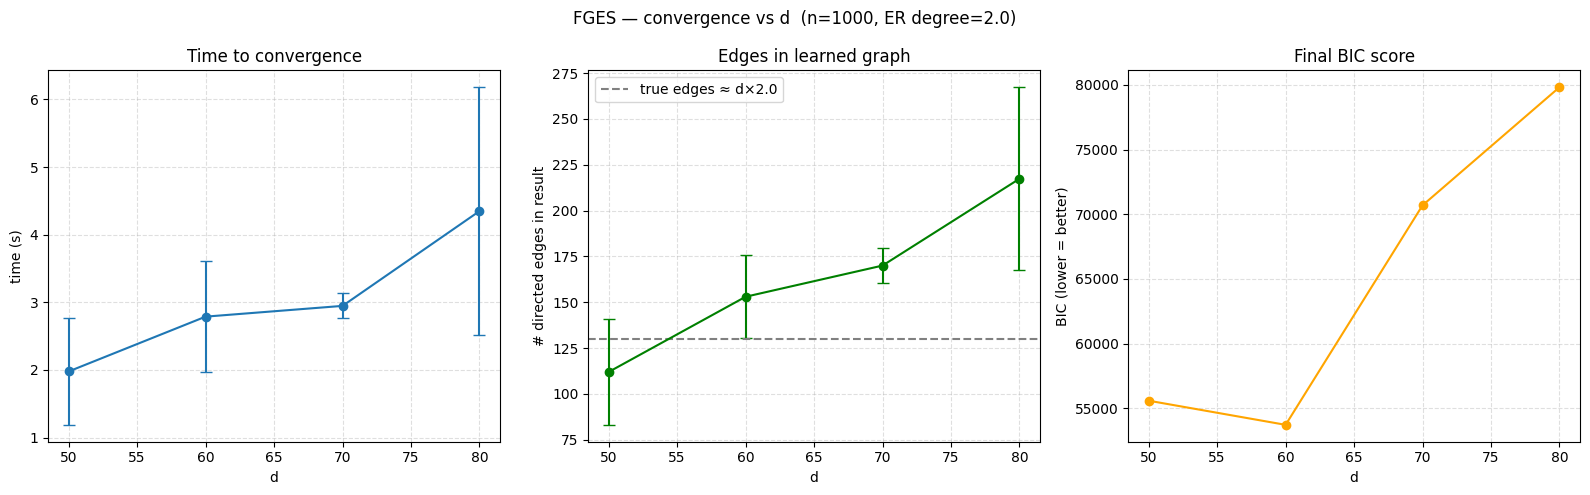

figure saved → /home/yin/DAG/experiments/results/fges_convergence.png


In [6]:
df_conv = df[df["converged"]]
agg = df_conv.groupby("d").agg(
    mean_time=("time_sec", "mean"),
    std_time=("time_sec", "std"),
    mean_edges=("n_edges", "mean"),
    std_edges=("n_edges", "std"),
    mean_bic=("bic", "mean"),
).reset_index()
print(agg.to_string(index=False))

if len(agg) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"{ALGO_NAME} — convergence vs d  (n={N_SAMPLES}, ER degree={DEGREE})",
                 fontsize=12)

    ax = axes[0]
    ax.errorbar(agg["d"], agg["mean_time"], yerr=agg["std_time"].fillna(0),
                fmt="o-", capsize=4)
    ax.set_xlabel("d"); ax.set_ylabel("time (s)")
    ax.set_title("Time to convergence")
    ax.grid(True, ls="--", alpha=0.4)

    ax = axes[1]
    ax.errorbar(agg["d"], agg["mean_edges"], yerr=agg["std_edges"].fillna(0),
                fmt="o-", capsize=4, color="green")
    ax.axhline(agg["d"].mean() * DEGREE, ls="--", color="gray",
               label=f"true edges ≈ d×{DEGREE}")
    ax.set_xlabel("d"); ax.set_ylabel("# directed edges in result")
    ax.set_title("Edges in learned graph")
    ax.legend(); ax.grid(True, ls="--", alpha=0.4)

    ax = axes[2]
    ax.plot(agg["d"], agg["mean_bic"], "o-", color="orange")
    ax.set_xlabel("d"); ax.set_ylabel("BIC (lower = better)")
    ax.set_title("Final BIC score")
    ax.grid(True, ls="--", alpha=0.4)

    plt.tight_layout()
    out_png = REPO_ROOT / "experiments" / "results" / f"{TAG}.png"
    plt.savefig(out_png, dpi=120)
    plt.show()
    print(f"figure saved → {out_png}")
else:
    print("Not enough data to plot.")

## 结论

In [7]:
n_total = len(df)
n_conv  = df["converged"].sum()
print(f"Converged: {n_conv}/{n_total} trials  (FGES always terminates naturally)")
if len(agg) >= 2:
    sl_t, _, r_t, *_ = stats.linregress(agg["d"], agg["mean_time"])
    sl_e, _, r_e, *_ = stats.linregress(agg["d"], agg["mean_edges"])
    print(f"  time  ~ {sl_t:.4f}s per d-unit  R²={r_t**2:.3f}")
    print(f"  edges ~ {sl_e:.2f} per d-unit   R²={r_e**2:.3f}")
    print(f"Config: penalty_discount={PENALTY_DISCOUNT}, n={N_SAMPLES}, degree={DEGREE}")

Converged: 12/12 trials  (FGES always terminates naturally)
  time  ~ 0.0727s per d-unit  R²=0.908
  edges ~ 3.33 per d-unit   R²=0.972
Config: penalty_discount=2, n=1000, degree=2.0
